# Entrega 02: Projeto Interdisciplinar: Ciência de Dados

**Estudantes:**

* André Gregório dos Santos – RA: 24026489
* Guilherme Reis Fogolin de Godoy – RA: 24026241
* Pedro Henrique Nascimento Lemos – RA: 23025380
* Yan Ramos Cezareto – RA: 24026005

🆘 Importante! Devidas descrições e demais informações estão disponíveis no arquivo PDF. Para acesso: [Entrega 02 - Professor Savino](https://github.com/2025-2-NCC4/Projeto6/tree/main/documentos/Entrega02/Projeto).

#Carregamento da base de dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from google.colab import files

# Carregamento dos arquivos

print("Arquivos no diretório atual: ", os.listdir())

try:
    # 1. Base de transações
    df_transacoes = pd.read_csv("/content/Base_de_Transacoes_Cupons_Capturados.csv", sep=';')

    # 2. Base cadastral de players
    df_players = pd.read_csv("/content/Base_Cadastral_de_Players.csv", sep=';')

    # 3. Base de Pedestres
    df_pedestres = pd.read_csv("/content/Base_Simulada_Pedestres_Av_Paulista.csv", sep=';')

    # 4. Base de lojas e valores)
    df_lojas_valores = pd.read_csv("/content/Base_de_Teste_com_Lojas_e_Valores.csv", sep=';')

    print("Arquivos carregados com sucesso!")
    print("Transações:", df_transacoes.shape)
    print("Players:", df_players.shape)
    print("Pedestres:", df_pedestres.shape)
    print("Lojas & Valores:", df_lojas_valores.shape)

except FileNotFoundError as e:
    print(f"Erro ao carregar o arquivo: {e}")
    problem_file = e.filename
    print(f"Por favor, selecione o arquivo '{os.path.basename(problem_file)}' para upload novamente.")
    uploaded_again = files.upload()

    if os.path.basename(problem_file) in uploaded_again:
        try:
            if 'Base_de_Teste_com_Lojas_e_Valores.csv' in uploaded_again:
                 df_lojas_valores = pd.read_csv("/content/Base_de_Teste_com_Lojas_e_Valores.csv", sep=';')
                 print(f"Arquivo '{os.path.basename(problem_file)}' carregado com sucesso após re-upload.")
            else:
                 print(f"O arquivo '{os.path.basename(problem_file)}' não foi selecionado no re-upload.")
        except Exception as inner_e:
            print(f"Erro ao carregar o arquivo após re-upload: {inner_e}")
    else:
         print("Nenhum arquivo foi selecionado para re-upload.")

except Exception as e:
    print(f"Ocorreu um erro inesperado durante o carregamento dos arquivos: {e}")

Arquivos no diretório atual:  ['.config', 'sample_data']
Erro ao carregar o arquivo: [Errno 2] No such file or directory: '/content/Base_de_Transacoes_Cupons_Capturados.csv'
Por favor, selecione o arquivo 'Base_de_Transacoes_Cupons_Capturados.csv' para upload novamente.


Saving Base_Cadastral_de_Players.csv to Base_Cadastral_de_Players.csv
Saving Base_de_Teste_com_Lojas_e_Valores.csv to Base_de_Teste_com_Lojas_e_Valores.csv
Saving Base_de_Transacoes_Cupons_Capturados.csv to Base_de_Transacoes_Cupons_Capturados.csv
Saving Base_Simulada_Pedestres_Av_Paulista.csv to Base_Simulada_Pedestres_Av_Paulista.csv
Arquivo 'Base_de_Transacoes_Cupons_Capturados.csv' carregado com sucesso após re-upload.


#Verificação da qualidade e limpeza dos dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("=" * 80)
print("🧹 PICMONEY - LIMPEZA E VERIFICAÇÃO DE QUALIDADE DOS DADOS")
print("=" * 80)


# FUNÇÃO AUXILIAR: CARREGAR CSV COM MÚLTIPLAS ESTRATÉGIAS

def carregar_csv_robusto(caminho_arquivo, nome_dataset):
    """
    Tenta carregar CSV com diferentes configurações até encontrar a correta.
    """
    print(f"\n📂 Carregando: {nome_dataset}")
    print(f"   Arquivo: {caminho_arquivo}")

    estrategias = [
        # Estratégia 1: Padrão
        {'sep': ',', 'encoding': 'utf-8', 'engine': 'python'},
        # Estratégia 2: Ponto e vírgula (comum em Excel Brasil)
        {'sep': ';', 'encoding': 'utf-8', 'engine': 'python'},
        # Estratégia 3: Tab
        {'sep': '\t', 'encoding': 'utf-8', 'engine': 'python'},
        # Estratégia 4: Vírgula com encoding latin1
        {'sep': ',', 'encoding': 'latin1', 'engine': 'python'},
        # Estratégia 5: Ponto e vírgula com latin1
        {'sep': ';', 'encoding': 'latin1', 'engine': 'python'},
        # Estratégia 6: Auto-detectar com on_bad_lines
        {'sep': ',', 'encoding': 'utf-8', 'on_bad_lines': 'skip', 'engine': 'python'},
        # Estratégia 7: Ponto e vírgula com on_bad_lines
        {'sep': ';', 'encoding': 'utf-8', 'on_bad_lines': 'skip', 'engine': 'python'},
    ]

    for i, config in enumerate(estrategias, 1):
        try:
            df = pd.read_csv(caminho_arquivo, **config)

            # Validar se o DataFrame faz sentido
            if len(df) > 0 and len(df.columns) > 1:
                print(f"   ✓ Carregado com sucesso (Estratégia {i})")
                print(f"   ✓ Configuração: {config}")
                print(f"   ✓ Shape: {df.shape}")
                return df
        except Exception as e:
            if i == len(estrategias):
                print(f"   ❌ Todas as estratégias falharam")
                print(f"   Último erro: {e}")

    return None


🧹 PICMONEY - LIMPEZA E VERIFICAÇÃO DE QUALIDADE DOS DADOS


In [ ]:
# ============================================================================
# ETAPA 1: CARREGAMENTO DOS DADOS COM TRATAMENTO DE ERROS
# ============================================================================

print("\n" + "=" * 80)
print("ETAPA 1: CARREGAMENTO DOS 4 DATASETS")
print("=" * 80)

datasets_info = {
    'df_players': {
        'arquivo': 'Base_Cadastral_de_Players.csv',
        'nome': 'BASE CADASTRAL DE PLAYERS'
    },
    'df_transacoes': {
        'arquivo': 'Base_de_Transacoes_Cupons_Capturados.csv',
        'nome': 'TRANSAÇÕES - CUPONS CAPTURADOS'
    },
    'df_pedestres': {
        'arquivo': 'Base_Simulada_Pedestres_Av_Paulista.csv',
        'nome': 'PEDESTRES AV. PAULISTA'
    },
    'df_lojas_valores': {
        'arquivo': 'Base_de_Teste_com_Lojas_e_Valores.csv',
        'nome': 'LOJAS E VALORES'
    }
}

# Dicionário para armazenar os DataFrames carregados
datasets = {}

# Carregar cada dataset
for var_name, info in datasets_info.items():
    df = carregar_csv_robusto(info['arquivo'], info['nome'])

    if df is not None:
        datasets[var_name] = df
        print(f"   ✓ {info['nome']}: Armazenado em '{var_name}'")
        print(f"   Colunas: {df.columns.tolist()[:5]}{'...' if len(df.columns) > 5 else ''}")
    else:
        print(f"   ❌ ERRO: Não foi possível carregar {info['nome']}")
        print(f"   Verifique o arquivo: {info['arquivo']}")
        raise FileNotFoundError(f"Não foi possível carregar {info['arquivo']}")

# Extrair DataFrames do dicionário
df_players = datasets['df_players']
df_transacoes = datasets['df_transacoes']
df_pedestres = datasets['df_pedestres']
df_lojas_valores = datasets['df_lojas_valores']

print("\n✅ Todos os 4 datasets carregados com sucesso!")

# Visualizar estrutura inicial
print("\n" + "=" * 80)
print("📊 ESTRUTURA INICIAL DOS DADOS")
print("=" * 80)

for var_name, info in datasets_info.items():
    df = datasets[var_name]
    print(f"\n{'─' * 80}")
    print(f"📋 {info['nome']}")
    print(f"{'─' * 80}")
    print(f"   Shape: {df.shape}")
    print(f"   Colunas ({len(df.columns)}): {df.columns.tolist()}")
    print(f"\n   Primeiras 3 linhas:")
    print(df.head(3))
    print(f"\n   Tipos de dados:")
    print(df.dtypes)



ETAPA 1: CARREGAMENTO DOS 4 DATASETS

📂 Carregando: BASE CADASTRAL DE PLAYERS
   Arquivo: Base_Cadastral_de_Players.csv
   ✓ Carregado com sucesso (Estratégia 2)
   ✓ Configuração: {'sep': ';', 'encoding': 'utf-8', 'engine': 'python'}
   ✓ Shape: (10000, 11)
   ✓ BASE CADASTRAL DE PLAYERS: Armazenado em 'df_players'
   Colunas: ['celular', 'data_nascimento', 'idade', 'sexo', 'cidade_residencial']...

📂 Carregando: TRANSAÇÕES - CUPONS CAPTURADOS
   Arquivo: Base_de_Transacoes_Cupons_Capturados.csv
   ✓ Carregado com sucesso (Estratégia 2)
   ✓ Configuração: {'sep': ';', 'encoding': 'utf-8', 'engine': 'python'}
   ✓ Shape: (100000, 12)
   ✓ TRANSAÇÕES - CUPONS CAPTURADOS: Armazenado em 'df_transacoes'
   Colunas: ['celular', 'data', 'hora', 'nome_estabelecimento', 'bairro_estabelecimento']...

📂 Carregando: PEDESTRES AV. PAULISTA
   Arquivo: Base_Simulada_Pedestres_Av_Paulista.csv
   ✓ Carregado com sucesso (Estratégia 2)
   ✓ Configuração: {'sep': ';', 'encoding': 'utf-8', 'engine': 'p

In [ ]:
#============================================================================
# ETAPA 2: FUNÇÃO DE LIMPEZA E VERIFICAÇÃO DE QUALIDADE
# ============================================================================

def verificar_qualidade(df, nome_df, cols_criticas=None):
    """
    Função que verifica e limpa os dados, reportando a qualidade.
    """
    print("\n" + "=" * 80)
    print(f"🔍 VERIFICANDO QUALIDADE: {nome_df}")
    print("=" * 80)

    df_limpo = df.copy()

    print(f"\n📊 Informações iniciais:")
    print(f"   • Shape original: {df_limpo.shape}")
    print(f"   • Memória utilizada: {df_limpo.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # ──────────────────────────────────────────────────────────────────────
    # 1. ANÁLISE DE VALORES AUSENTES
    # ──────────────────────────────────────────────────────────────────────
    print(f"\n1️⃣ ANÁLISE DE VALORES AUSENTES:")
    valores_ausentes = df_limpo.isnull().sum()
    pct_ausentes = (valores_ausentes / len(df_limpo) * 100).round(2)

    if valores_ausentes.sum() > 0:
        print("\n   Valores ausentes por coluna:")
        for col, count in valores_ausentes[valores_ausentes > 0].items():
            print(f"   • {col}: {count:,} ({pct_ausentes[col]}%)")
    else:
        print("   ✓ Nenhum valor ausente encontrado!")

    # Remover linhas com valores ausentes em colunas críticas
    if cols_criticas:
        cols_existentes = [col for col in cols_criticas if col in df_limpo.columns]
        cols_faltantes = [col for col in cols_criticas if col not in df_limpo.columns]

        if cols_faltantes:
            print(f"\n   ⚠️ Colunas críticas não encontradas: {cols_faltantes}")

        if cols_existentes:
            linhas_antes = len(df_limpo)
            df_limpo = df_limpo.dropna(subset=cols_existentes)
            linhas_removidas = linhas_antes - len(df_limpo)

            if linhas_removidas > 0:
                print(f"\n   🗑️ Removidas {linhas_removidas:,} linhas com valores ausentes em colunas críticas")
            else:
                print(f"\n   ✓ Nenhuma linha removida (colunas críticas completas)")

    # ──────────────────────────────────────────────────────────────────────
    # 2. ANÁLISE DE DUPLICATAS
    # ──────────────────────────────────────────────────────────────────────
    print(f"\n2️⃣ ANÁLISE DE DUPLICATAS:")
    duplicatas = df_limpo.duplicated().sum()

    if duplicatas > 0:
        print(f"   ⚠️ Encontradas {duplicatas:,} linhas duplicadas ({duplicatas/len(df_limpo)*100:.2f}%)")
        df_limpo = df_limpo.drop_duplicates()
        print(f"   ✓ Duplicatas removidas")
    else:
        print(f"   ✓ Nenhuma duplicata encontrada")

    # ──────────────────────────────────────────────────────────────────────
    # 3. CONVERSÃO E VALIDAÇÃO DE DATAS
    # ──────────────────────────────────────────────────────────────────────
    print(f"\n3️⃣ CONVERSÃO DE DATAS:")
    colunas_data = ['data', 'data_captura', 'data_ultima_compra']

    datas_convertidas = 0
    for col in colunas_data:
        if col in df_limpo.columns:
            try:
                df_limpo[col] = pd.to_datetime(df_limpo[col], errors='coerce', dayfirst=True)
                datas_invalidas = df_limpo[col].isnull().sum()

                if datas_invalidas > 0:
                    print(f"   ⚠️ '{col}': {datas_invalidas:,} datas inválidas (convertidas para NaT)")
                else:
                    print(f"   ✓ '{col}': Todas as datas convertidas com sucesso")
                    print(f"      Período: {df_limpo[col].min()} até {df_limpo[col].max()}")

                datas_convertidas += 1
            except Exception as e:
                print(f"   ❌ Erro ao converter '{col}': {e}")

    if datas_convertidas == 0:
        print("   ℹ️ Nenhuma coluna de data encontrada neste dataset")

    # ──────────────────────────────────────────────────────────────────────
    # 4. CONVERSÃO E VALIDAÇÃO DE VALORES NUMÉRICOS
    # ──────────────────────────────────────────────────────────────────────
    print(f"\n4️⃣ CONVERSÃO DE VALORES NUMÉRICOS:")
    colunas_valor = ['valor_compra', 'valor_cupom', 'repasse_picmoney', 'idade']

    valores_convertidos = 0
    for col in colunas_valor:
        if col in df_limpo.columns:
            try:
                if df_limpo[col].dtype == 'object':
                    df_limpo[col] = (df_limpo[col]
                                     .astype(str)
                                     .str.replace('R$', '', regex=False)
                                     .str.replace(',', '.')
                                     .str.strip())

                df_limpo[col] = pd.to_numeric(df_limpo[col], errors='coerce')
                valores_invalidos = df_limpo[col].isnull().sum()

                if valores_invalidos > 0:
                    print(f"   ⚠️ '{col}': {valores_invalidos:,} valores inválidos")
                else:
                    print(f"   ✓ '{col}': Convertido com sucesso")
                    print(f"      Min: {df_limpo[col].min():.2f} | Max: {df_limpo[col].max():.2f} | Média: {df_limpo[col].mean():.2f}")

                valores_convertidos += 1
            except Exception as e:
                print(f"   ❌ Erro ao converter '{col}': {e}")

    if valores_convertidos == 0:
        print("   ℹ️ Nenhuma coluna numérica específica encontrada para conversão")

    # ──────────────────────────────────────────────────────────────────────
    # 5. LIMPEZA DE TEXTO
    # ──────────────────────────────────────────────────────────────────────
    print(f"\n5️⃣ LIMPEZA DE COLUNAS DE TEXTO:")

    if 'celular' in df_limpo.columns:
        df_limpo['celular'] = df_limpo['celular'].astype(str).str.strip()
        celulares_unicos = df_limpo['celular'].nunique()
        print(f"   ✓ 'celular': Espaços removidos")
        print(f"      Celulares únicos: {celulares_unicos:,}")

    colunas_texto = df_limpo.select_dtypes(include=['object']).columns
    for col in colunas_texto:
        if col != 'celular':
            df_limpo[col] = df_limpo[col].astype(str).str.strip()

    if len(colunas_texto) > 0:
        print(f"   ✓ {len(colunas_texto)} colunas de texto limpas (espaços removidos)")

    # ──────────────────────────────────────────────────────────────────────
    # RESUMO FINAL
    # ──────────────────────────────────────────────────────────────────────
    print(f"\n{'─' * 80}")
    print(f"✅ LIMPEZA CONCLUÍDA: {nome_df}")
    print(f"{'─' * 80}")
    print(f"   • Shape final: {df_limpo.shape}")
    print(f"   • Registros mantidos: {len(df_limpo):,} ({len(df_limpo)/len(df)*100:.1f}%)")
    print(f"   • Registros removidos: {len(df) - len(df_limpo):,}")
    print(f"   • Memória final: {df_limpo.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("=" * 80)

    return df_limpo



In [ ]:
# ============================================================================
# ETAPA 3: APLICAR LIMPEZA EM TODOS OS DATASETS
# ============================================================================

print("\n" + "=" * 80)
print("🧹 INICIANDO LIMPEZA DOS 4 DATASETS")
print("=" * 80)

# Definir colunas críticas dinamicamente baseado nas colunas existentes
def get_colunas_criticas(df, tipo):
    """Retorna colunas críticas que existem no DataFrame"""
    todas_criticas = {
        'players': ['celular', 'idade', 'sexo'],
        'transacoes': ['data', 'categoria_estabelecimento', 'repasse_picmoney', 'celular'],
        'pedestres': ['idade', 'sexo'],
        'lojas_valores': ['data_captura', 'nome_loja', 'valor_compra', 'valor_cupom', 'tipo_loja']
    }

    return [col for col in todas_criticas[tipo] if col in df.columns]

# 1. Limpar Players
df_players_limpo = verificar_qualidade(
    df_players,
    "BASE CADASTRAL DE PLAYERS",
    cols_criticas=get_colunas_criticas(df_players, 'players')
)

# 2. Limpar Transações
df_transacoes_limpo = verificar_qualidade(
    df_transacoes,
    "TRANSAÇÕES - CUPONS CAPTURADOS",
    cols_criticas=get_colunas_criticas(df_transacoes, 'transacoes')
)

# 3. Limpar Pedestres
df_pedestres_limpo = verificar_qualidade(
    df_pedestres,
    "PEDESTRES AV. PAULISTA",
    cols_criticas=get_colunas_criticas(df_pedestres, 'pedestres')
)

# 4. Limpar Lojas e Valores
df_lojas_valores_limpo = verificar_qualidade(
    df_lojas_valores,
    "LOJAS E VALORES",
    cols_criticas=get_colunas_criticas(df_lojas_valores, 'lojas_valores')
)




🧹 INICIANDO LIMPEZA DOS 4 DATASETS

🔍 VERIFICANDO QUALIDADE: BASE CADASTRAL DE PLAYERS

📊 Informações iniciais:
   • Shape original: (10000, 11)
   • Memória utilizada: 5.84 MB

1️⃣ ANÁLISE DE VALORES AUSENTES:

   Valores ausentes por coluna:
   • cidade_trabalho: 3,969 (39.69%)
   • bairro_trabalho: 3,969 (39.69%)
   • cidade_escola: 6,932 (69.32%)
   • bairro_escola: 6,932 (69.32%)

   ✓ Nenhuma linha removida (colunas críticas completas)

2️⃣ ANÁLISE DE DUPLICATAS:
   ✓ Nenhuma duplicata encontrada

3️⃣ CONVERSÃO DE DATAS:
   ℹ️ Nenhuma coluna de data encontrada neste dataset

4️⃣ CONVERSÃO DE VALORES NUMÉRICOS:
   ✓ 'idade': Convertido com sucesso
      Min: 16.00 | Max: 91.00 | Média: 52.79

5️⃣ LIMPEZA DE COLUNAS DE TEXTO:
   ✓ 'celular': Espaços removidos
      Celulares únicos: 9,999
   ✓ 10 colunas de texto limpas (espaços removidos)

────────────────────────────────────────────────────────────────────────────────
✅ LIMPEZA CONCLUÍDA: BASE CADASTRAL DE PLAYERS
──────────────

In [ ]:
# ============================================================================
# RESUMO FINAL
# ============================================================================

print("\n" + "=" * 80)
print("📊 RESUMO FINAL - TODOS OS DATASETS LIMPOS")
print("=" * 80)

datasets_resumo = {
    'Players': (df_players, df_players_limpo),
    'Transações': (df_transacoes, df_transacoes_limpo),
    'Pedestres': (df_pedestres, df_pedestres_limpo),
    'Lojas e Valores': (df_lojas_valores, df_lojas_valores_limpo)
}

print("\n┌─────────────────────────────┬──────────────┬──────────────┬─────────────┐")
print("│ Dataset                     │ Original     │ Limpo        │ % Mantido   │")
print("├─────────────────────────────┼──────────────┼──────────────┼─────────────┤")

for nome, (df_orig, df_limp) in datasets_resumo.items():
    pct_mantido = (len(df_limp) / len(df_orig) * 100)
    print(f"│ {nome:27} │ {len(df_orig):12,} │ {len(df_limp):12,} │ {pct_mantido:10.1f}% │")

print("└─────────────────────────────┴──────────────┴──────────────┴─────────────┘")

print("\n✅ TODOS OS DATASETS FORAM LIMPOS E ESTÃO PRONTOS PARA INTEGRAÇÃO!")
print("\n📦 DataFrames limpos disponíveis:")
print("  • df_players_limpo")
print("  • df_transacoes_limpo")
print("  • df_pedestres_limpo")
print("  • df_lojas_valores_limpo")

print("\n" + "=" * 80)


📊 RESUMO FINAL - TODOS OS DATASETS LIMPOS

┌─────────────────────────────┬──────────────┬──────────────┬─────────────┐
│ Dataset                     │ Original     │ Limpo        │ % Mantido   │
├─────────────────────────────┼──────────────┼──────────────┼─────────────┤
│ Players                     │       10,000 │       10,000 │      100.0% │
│ Transações                  │      100,000 │      100,000 │      100.0% │
│ Pedestres                   │      100,000 │      100,000 │      100.0% │
│ Lojas e Valores             │       10,000 │       10,000 │      100.0% │
└─────────────────────────────┴──────────────┴──────────────┴─────────────┘

✅ TODOS OS DATASETS FORAM LIMPOS E ESTÃO PRONTOS PARA INTEGRAÇÃO!

📦 DataFrames limpos disponíveis:
  • df_players_limpo
  • df_transacoes_limpo
  • df_pedestres_limpo
  • df_lojas_valores_limpo



#Integração dos dados

In [ ]:
import pandas as pd
import numpy as np

print("=" * 80)
print("🔗 INTEGRAÇÃO DOS DATASETS PICMONEY")
print("=" * 80)

# ============================================================================
# VERIFICAR ESTRUTURA DOS DATAFRAMES LIMPOS
# ============================================================================

print("\n📊 ESTRUTURA DOS DATAFRAMES DISPONÍVEIS:")
print("-" * 80)

print(f"\n1. df_players_limpo:")
print(f"   Shape: {df_players_limpo.shape}")
print(f"   Colunas: {df_players_limpo.columns.tolist()}")

print(f"\n2. df_transacoes_limpo:")
print(f"   Shape: {df_transacoes_limpo.shape}")
print(f"   Colunas: {df_transacoes_limpo.columns.tolist()}")

print(f"\n3. df_lojas_valores_limpo:")
print(f"   Shape: {df_lojas_valores_limpo.shape}")
print(f"   Colunas: {df_lojas_valores_limpo.columns.tolist()}")

print(f"\n4. df_pedestres_limpo:")
print(f"   Shape: {df_pedestres_limpo.shape}")
print(f"   Colunas: {df_pedestres_limpo.columns.tolist()}")



🔗 INTEGRAÇÃO DOS DATASETS PICMONEY

📊 ESTRUTURA DOS DATAFRAMES DISPONÍVEIS:
--------------------------------------------------------------------------------

1. df_players_limpo:
   Shape: (10000, 11)
   Colunas: ['celular', 'data_nascimento', 'idade', 'sexo', 'cidade_residencial', 'bairro_residencial', 'cidade_trabalho', 'bairro_trabalho', 'cidade_escola', 'bairro_escola', 'categoria_frequentada']

2. df_transacoes_limpo:
   Shape: (100000, 12)
   Colunas: ['celular', 'data', 'hora', 'nome_estabelecimento', 'bairro_estabelecimento', 'categoria_estabelecimento', 'id_campanha', 'id_cupom', 'tipo_cupom', 'produto', 'valor_cupom', 'repasse_picmoney']

3. df_lojas_valores_limpo:
   Shape: (10000, 11)
   Colunas: ['numero_celular', 'data_captura', 'tipo_cupom', 'tipo_loja', 'local_captura', 'latitude', 'longitude', 'nome_loja', 'endereco_loja', 'valor_compra', 'valor_cupom']

4. df_pedestres_limpo:
   Shape: (100000, 15)
   Colunas: ['celular', 'data', 'horario', 'local', 'latitude', 'longi

In [ ]:
# ============================================================================
# IDENTIFICAR COLUNAS DE LIGAÇÃO (CHAVES)
# ============================================================================

print("\n" + "=" * 80)
print("🔍 IDENTIFICANDO COLUNAS DE LIGAÇÃO (CHAVES)")
print("=" * 80)

# Verificar se existe 'celular' em cada dataset
print("\n📱 Coluna 'celular' presente em:")
for nome, df in [('players', df_players_limpo),
                 ('transacoes', df_transacoes_limpo),
                 ('lojas_valores', df_lojas_valores_limpo),
                 ('pedestres', df_pedestres_limpo)]:
    if 'celular' in df.columns:
        print(f"   ✓ {nome}: {df['celular'].nunique():,} celulares únicos")
    else:
        print(f"   ✗ {nome}: NÃO possui coluna 'celular'")




🔍 IDENTIFICANDO COLUNAS DE LIGAÇÃO (CHAVES)

📱 Coluna 'celular' presente em:
   ✓ players: 9,999 celulares únicos
   ✓ transacoes: 4,813 celulares únicos
   ✗ lojas_valores: NÃO possui coluna 'celular'
   ✓ pedestres: 99,935 celulares únicos


In [ ]:
# ============================================================================
# ESTRATÉGIA DE INTEGRAÇÃO
# ============================================================================

print("\n" + "=" * 80)
print("📋 ESTRATÉGIA DE INTEGRAÇÃO")
print("=" * 80)

print("\n🎯 Plano de integração:")
print("   1. TRANSAÇÕES + PLAYERS (por 'celular')")
print("   2. Resultado + LOJAS_VALORES (por 'celular' se existir, senão por categoria)")
print("   3. PEDESTRES (mantido separado - dataset de comparação)")




📋 ESTRATÉGIA DE INTEGRAÇÃO

🎯 Plano de integração:
   1. TRANSAÇÕES + PLAYERS (por 'celular')
   2. Resultado + LOJAS_VALORES (por 'celular' se existir, senão por categoria)
   3. PEDESTRES (mantido separado - dataset de comparação)


In [ ]:
# ============================================================================
# PASSO 1: TRANSAÇÕES + PLAYERS
# ============================================================================

print("\n" + "=" * 80)
print("🔗 PASSO 1: INTEGRANDO TRANSAÇÕES + PLAYERS")
print("=" * 80)

# Preparar DataFrames
df_trans = df_transacoes_limpo.copy()
df_play = df_players_limpo.copy()

# Garantir que 'celular' é string e está limpo
df_trans['celular'] = df_trans['celular'].astype(str).str.strip()
df_play['celular'] = df_play['celular'].astype(str).str.strip()

# Remover duplicatas de players (manter apenas 1 registro por celular)
df_play = df_play.drop_duplicates(subset=['celular'], keep='first')

print(f"\nℹ️ Transações: {len(df_trans):,} registros, {df_trans['celular'].nunique():,} celulares únicos")
print(f"ℹ️ Players: {len(df_play):,} registros únicos")

# Fazer o merge
df_integrado_1 = pd.merge(
    df_trans,
    df_play,
    on='celular',
    how='left',
    suffixes=('', '_player')
)

print(f"\n✅ Resultado: {df_integrado_1.shape}")
print(f"   Registros: {len(df_integrado_1):,}")
print(f"   Colunas: {len(df_integrado_1.columns)}")

# Verificar quantos matches foram feitos
matches = df_integrado_1['celular'].isin(df_play['celular']).sum()
print(f"   Matches encontrados: {matches:,} ({matches/len(df_integrado_1)*100:.1f}%)")




🔗 PASSO 1: INTEGRANDO TRANSAÇÕES + PLAYERS

ℹ️ Transações: 100,000 registros, 4,813 celulares únicos
ℹ️ Players: 9,999 registros únicos

✅ Resultado: (100000, 22)
   Registros: 100,000
   Colunas: 22
   Matches encontrados: 100,000 (100.0%)


In [ ]:
# ============================================================================
# PASSO 2: ADICIONAR LOJAS_VALORES
# ============================================================================

print("\n" + "=" * 80)
print("🔗 PASSO 2: ADICIONANDO LOJAS_VALORES")
print("=" * 80)

df_valores = df_lojas_valores_limpo.copy()

# Verificar se lojas_valores tem coluna 'celular'
if 'celular' in df_valores.columns:
    print("\n✓ Lojas_valores TEM coluna 'celular' - fazendo join direto")

    df_valores['celular'] = df_valores['celular'].astype(str).str.strip()

    df_final = pd.merge(
        df_integrado_1,
        df_valores,
        on='celular',
        how='left',
        suffixes=('', '_loja')
    )

    print(f"\n✅ Join direto por 'celular'")

else:
    print("\n⚠️ Lojas_valores NÃO tem coluna 'celular'")
    print("   Estratégia alternativa: Agregar valores por 'tipo_loja' e fazer join por categoria")

    # Agregar valores por tipo_loja
    df_valores_agg = df_valores.groupby('tipo_loja').agg({
        'valor_compra': ['mean', 'sum', 'count'],
        'valor_cupom': ['mean', 'sum']
    }).reset_index()

    # Renomear colunas
    df_valores_agg.columns = [
        'tipo_loja',
        'valor_compra_medio', 'valor_compra_total', 'qtd_cupons',
        'valor_cupom_medio', 'valor_cupom_total'
    ]

    print(f"\n📊 Valores agregados por tipo_loja:")
    print(df_valores_agg)

    # Mapear categoria_estabelecimento -> tipo_loja
    # (assumindo que os nomes são similares ou iguais)
    df_integrado_1['tipo_loja'] = df_integrado_1['categoria_estabelecimento']

    # Fazer o merge por tipo_loja
    df_final = pd.merge(
        df_integrado_1,
        df_valores_agg,
        on='tipo_loja',
        how='left'
    )

    print(f"\n✅ Join por 'tipo_loja' (valores agregados)")

print(f"\nℹ️ Resultado final: {df_final.shape}")
print(f"   Registros: {len(df_final):,}")
print(f"   Colunas: {len(df_final.columns)}")




🔗 PASSO 2: ADICIONANDO LOJAS_VALORES

⚠️ Lojas_valores NÃO tem coluna 'celular'
   Estratégia alternativa: Agregar valores por 'tipo_loja' e fazer join por categoria

📊 Valores agregados por tipo_loja:
         tipo_loja  valor_compra_medio  valor_compra_total  qtd_cupons  \
0  eletrodoméstico          537.656259           676909.23        1259   
1        esportivo          545.694022           733958.46        1345   
2         farmácia          556.107917           696803.22        1253   
3  mercado express          553.027568           666398.22        1205   
4           móveis          550.019291           682573.94        1241   
5           outros          555.999365           664975.24        1196   
6      restaurante          547.225418           673634.49        1231   
7        vestuário          552.431457           701587.95        1270   

   valor_cupom_medio  valor_cupom_total  
0          67.768801           85320.92  
1          69.177264           93043.42  
2   

In [ ]:
# ============================================================================
# RESUMO DA INTEGRAÇÃO
# ============================================================================

print("\n" + "=" * 80)
print("📊 RESUMO DA INTEGRAÇÃO")
print("=" * 80)

print(f"\n✅ DataFrame Integrado Criado: df_final")
print(f"   • Total de registros: {len(df_final):,}")
print(f"   • Total de colunas: {len(df_final.columns)}")
print(f"   • Celulares únicos: {df_final['celular'].nunique():,}")

print(f"\n📋 Todas as colunas do DataFrame final ({len(df_final.columns)}):")
for i, col in enumerate(df_final.columns, 1):
    tipo = df_final[col].dtype
    nulos = df_final[col].isnull().sum()
    print(f"   {i:2d}. {col:30s} | Tipo: {str(tipo):10s} | Nulos: {nulos:,}")

print(f"\n📊 Primeiras 5 linhas do DataFrame integrado:")
print(df_final.head())

print(f"\n📈 Estatísticas de valores nulos:")
nulls = df_final.isnull().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]
if len(nulls) > 0:
    print(f"\n   Colunas com valores nulos:")
    for col, count in nulls.items():
        pct = (count / len(df_final) * 100)
        print(f"   • {col}: {count:,} ({pct:.1f}%)")
else:
    print("   ✓ Nenhum valor nulo encontrado!")

print("\n" + "=" * 80)
print("✅ INTEGRAÇÃO CONCLUÍDA!")
print("=" * 80)

print("\n💾 DataFrames disponíveis:")
print("   • df_final - Dataset integrado (transações + players + lojas_valores)")
print("   • df_pedestres_limpo - Dataset separado para comparação")

print("\n" + "=" * 80)


📊 RESUMO DA INTEGRAÇÃO

✅ DataFrame Integrado Criado: df_final
   • Total de registros: 100,000
   • Total de colunas: 28
   • Celulares únicos: 4,813

📋 Todas as colunas do DataFrame final (28):
    1. celular                        | Tipo: object     | Nulos: 0
    2. data                           | Tipo: datetime64[ns] | Nulos: 0
    3. hora                           | Tipo: object     | Nulos: 0
    4. nome_estabelecimento           | Tipo: object     | Nulos: 0
    5. bairro_estabelecimento         | Tipo: object     | Nulos: 0
    6. categoria_estabelecimento      | Tipo: object     | Nulos: 0
    7. id_campanha                    | Tipo: object     | Nulos: 0
    8. id_cupom                       | Tipo: object     | Nulos: 0
    9. tipo_cupom                     | Tipo: object     | Nulos: 0
   10. produto                        | Tipo: object     | Nulos: 0
   11. valor_cupom                    | Tipo: float64    | Nulos: 0
   12. repasse_picmoney               | Tipo: float

#  Derivação de dados

In [ ]:
import pandas as pd
import numpy as np

print("=" * 80)
print("📊 DERIVAÇÃO DE DADOS - CRIAÇÃO DE KPIs E VARIÁVEIS CALCULADAS")
print("=" * 80)

# ============================================================================
# VERIFICAR ESTRUTURA DO DATAFRAME INTEGRADO
# ============================================================================

print("\n🔍 Verificando estrutura do df_final...")
print(f"   Shape: {df_final.shape}")
print(f"   Colunas disponíveis: {df_final.columns.tolist()}")

# ============================================================================
# 1. VARIÁVEIS TEMPORAIS
# ============================================================================

print("\n" + "=" * 80)
print("📅 1. CRIANDO VARIÁVEIS TEMPORAIS")
print("=" * 80)

if 'data' in df_final.columns:
    # Garantir que 'data' está em formato datetime
    df_final['data'] = pd.to_datetime(df_final['data'], errors='coerce')

    # Extrair componentes temporais
    df_final['ano'] = df_final['data'].dt.year
    df_final['mes'] = df_final['data'].dt.month
    df_final['mes_ano'] = df_final['data'].dt.to_period('M').astype(str)
    df_final['dia'] = df_final['data'].dt.day
    df_final['dia_semana'] = df_final['data'].dt.dayofweek  # 0=Segunda, 6=Domingo
    df_final['nome_dia_semana'] = df_final['data'].dt.day_name()
    df_final['semana_ano'] = df_final['data'].dt.isocalendar().week
    df_final['trimestre'] = df_final['data'].dt.quarter

    # Se houver informação de hora
    if df_final['data'].dt.hour.sum() > 0:
        df_final['hora'] = df_final['data'].dt.hour
        print("   ✓ Hora extraída")

    print("   ✓ Variáveis temporais criadas:")
    print("      • ano, mes, mes_ano, dia")
    print("      • dia_semana, nome_dia_semana, semana_ano")
    print("      • trimestre")

    # Mostrar exemplo
    print("\n   📊 Exemplo:")
    cols_temp = ['data', 'ano', 'mes', 'mes_ano', 'nome_dia_semana', 'trimestre']
    print(df_final[cols_temp].head(3))

else:
    print("   ⚠️ Coluna 'data' não encontrada!")



📊 DERIVAÇÃO DE DADOS - CRIAÇÃO DE KPIs E VARIÁVEIS CALCULADAS

🔍 Verificando estrutura do df_final...
   Shape: (100000, 28)
   Colunas disponíveis: ['celular', 'data', 'hora', 'nome_estabelecimento', 'bairro_estabelecimento', 'categoria_estabelecimento', 'id_campanha', 'id_cupom', 'tipo_cupom', 'produto', 'valor_cupom', 'repasse_picmoney', 'data_nascimento', 'idade', 'sexo', 'cidade_residencial', 'bairro_residencial', 'cidade_trabalho', 'bairro_trabalho', 'cidade_escola', 'bairro_escola', 'categoria_frequentada', 'tipo_loja', 'valor_compra_medio', 'valor_compra_total', 'qtd_cupons', 'valor_cupom_medio', 'valor_cupom_total']

📅 1. CRIANDO VARIÁVEIS TEMPORAIS
   ✓ Variáveis temporais criadas:
      • ano, mes, mes_ano, dia
      • dia_semana, nome_dia_semana, semana_ano
      • trimestre

   📊 Exemplo:
        data   ano  mes  mes_ano nome_dia_semana  trimestre
0 2025-07-10  2025    7  2025-07        Thursday          3
1 2025-07-15  2025    7  2025-07         Tuesday          3
2 2025-

In [ ]:
# ============================================================================
# 2. KPIs FINANCEIROS (CFO)
# ============================================================================

print("\n" + "=" * 80)
print("💰 2. CRIANDO KPIs FINANCEIROS (CFO)")
print("=" * 80)

# 2.1 Margem PicMoney
print("\n📈 2.1 Calculando Margem PicMoney...")

# Identificar qual coluna de valor_cupom usar
col_valor_cupom = None
if 'valor_cupom_medio' in df_final.columns:
    col_valor_cupom = 'valor_cupom_medio'
elif 'valor_cupom' in df_final.columns:
    col_valor_cupom = 'valor_cupom'
elif 'valor_cupom_cupom' in df_final.columns:
    col_valor_cupom = 'valor_cupom_cupom'

if 'repasse_picmoney' in df_final.columns and col_valor_cupom:
    # Margem = Repasse / Valor do Cupom
    df_final['margem_picmoney'] = df_final['repasse_picmoney'] / df_final[col_valor_cupom]

    # Limpar valores infinitos e NaN
    df_final['margem_picmoney'].replace([np.inf, -np.inf], np.nan, inplace=True)

    # Contar valores problemáticos
    nulos_antes = df_final['margem_picmoney'].isnull().sum()

    print(f"   ✓ Margem calculada usando '{col_valor_cupom}'")
    print(f"   ℹ️ Valores nulos/infinitos: {nulos_antes:,} ({nulos_antes/len(df_final)*100:.1f}%)")
    print(f"   ℹ️ Margem média: {df_final['margem_picmoney'].mean():.2%}")
    print(f"   ℹ️ Margem mediana: {df_final['margem_picmoney'].median():.2%}")

else:
    print(f"   ⚠️ Não foi possível calcular margem")
    print(f"      repasse_picmoney presente: {'repasse_picmoney' in df_final.columns}")
    print(f"      valor_cupom presente: {col_valor_cupom is not None}")

# 2.2 Percentual de Desconto do Cupom
print("\n📉 2.2 Calculando Percentual de Desconto...")

# Identificar coluna de valor_compra
col_valor_compra = None
if 'valor_compra_medio' in df_final.columns:
    col_valor_compra = 'valor_compra_medio'
elif 'valor_compra' in df_final.columns:
    col_valor_compra = 'valor_compra'

if col_valor_cupom and col_valor_compra:
    # Percentual de Desconto = Valor Cupom / Valor Compra
    df_final['pct_desconto_cupom'] = (df_final[col_valor_cupom] / df_final[col_valor_compra]) * 100

    # Limpar valores infinitos
    df_final['pct_desconto_cupom'].replace([np.inf, -np.inf], np.nan, inplace=True)

    print(f"   ✓ Percentual de desconto calculado")
    print(f"   ℹ️ Desconto médio: {df_final['pct_desconto_cupom'].mean():.1f}%")
    print(f"   ℹ️ Desconto mediano: {df_final['pct_desconto_cupom'].median():.1f}%")

else:
    print(f"   ⚠️ Não foi possível calcular percentual de desconto")

# 2.3 Valor Líquido para PicMoney
print("\n💵 2.3 Calculando Valor Líquido...")

if 'repasse_picmoney' in df_final.columns and col_valor_cupom:
    # Valor Líquido = Valor Cupom - Repasse
    df_final['valor_liquido_picmoney'] = df_final[col_valor_cupom] - df_final['repasse_picmoney']

    print(f"   ✓ Valor líquido calculado")
    print(f"   ℹ️ Valor líquido médio: R$ {df_final['valor_liquido_picmoney'].mean():.2f}")




💰 2. CRIANDO KPIs FINANCEIROS (CFO)

📈 2.1 Calculando Margem PicMoney...
   ✓ Margem calculada usando 'valor_cupom_medio'
   ℹ️ Valores nulos/infinitos: 100,000 (100.0%)
   ℹ️ Margem média: nan%
   ℹ️ Margem mediana: nan%

📉 2.2 Calculando Percentual de Desconto...
   ✓ Percentual de desconto calculado
   ℹ️ Desconto médio: nan%
   ℹ️ Desconto mediano: nan%

💵 2.3 Calculando Valor Líquido...
   ✓ Valor líquido calculado
   ℹ️ Valor líquido médio: R$ nan


/tmp/ipython-input-152295919.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['margem_picmoney'].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-152295919.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [ ]:
# ============================================================================
# 3. KPIs DE NEGÓCIO (CEO)
# ============================================================================

print("\n" + "=" * 80)
print("📊 3. CRIANDO KPIs DE NEGÓCIO (CEO)")
print("=" * 80)

# 3.1 Ticket Médio
print("\n🎫 3.1 Ticket Médio...")

if col_valor_compra:
    df_final['ticket_medio_compra'] = df_final[col_valor_compra]
    print(f"   ✓ Ticket médio atribuído")
    print(f"   ℹ️ Ticket médio geral: R$ {df_final['ticket_medio_compra'].mean():.2f}")

# 3.2 Valor do Repasse (simplificado para análise)
if 'repasse_picmoney' in df_final.columns:
    df_final['repasse_real'] = df_final['repasse_picmoney']
    print(f"\n💸 3.2 Repasse Real")
    print(f"   ✓ Repasse médio: R$ {df_final['repasse_real'].mean():.2f}")
    print(f"   ℹ️ Repasse total: R$ {df_final['repasse_real'].sum():,.2f}")




📊 3. CRIANDO KPIs DE NEGÓCIO (CEO)

🎫 3.1 Ticket Médio...
   ✓ Ticket médio atribuído
   ℹ️ Ticket médio geral: R$ nan

💸 3.2 Repasse Real
   ✓ Repasse médio: R$ 70.47
   ℹ️ Repasse total: R$ 7,047,473.91


In [ ]:
# ============================================================================
# 4. VARIÁVEIS DEMOGRÁFICAS DERIVADAS
# ============================================================================

print("\n" + "=" * 80)
print("👥 4. CRIANDO VARIÁVEIS DEMOGRÁFICAS DERIVADAS")
print("=" * 80)

# 4.1 Faixa Etária
if 'idade' in df_final.columns:
    df_final['faixa_etaria'] = pd.cut(
        df_final['idade'],
        bins=[0, 18, 25, 35, 45, 60, 100],
        labels=['<18', '18-25', '26-35', '36-45', '46-60', '60+'],
        include_lowest=True
    )

    print("\n👶 4.1 Faixa Etária:")
    print(f"   ✓ Faixa etária criada")
    print("\n   Distribuição:")
    print(df_final['faixa_etaria'].value_counts().sort_index())

else:
    print("\n   ⚠️ Coluna 'idade' não encontrada")

# 4.2 Segmento de Idade (simplificado)
if 'idade' in df_final.columns:
    df_final['segmento_idade'] = df_final['idade'].apply(
        lambda x: 'Jovem' if x < 30 else ('Adulto' if x < 60 else 'Senior')
    )
    print("\n   ✓ Segmento de idade criado (Jovem/Adulto/Senior)")




👥 4. CRIANDO VARIÁVEIS DEMOGRÁFICAS DERIVADAS

👶 4.1 Faixa Etária:
   ✓ Faixa etária criada

   Distribuição:
faixa_etaria
<18       4176
18-25     8572
26-35    13410
36-45    13366
46-60    20522
60+      39954
Name: count, dtype: int64

   ✓ Segmento de idade criado (Jovem/Adulto/Senior)


In [ ]:
# ============================================================================
# 5. VARIÁVEIS DE COMPORTAMENTO
# ============================================================================

print("\n" + "=" * 80)
print("🎯 5. CRIANDO VARIÁVEIS DE COMPORTAMENTO")
print("=" * 80)

# 5.1 Frequência de transações por celular
print("\n📱 5.1 Frequência de transações...")

if 'celular' in df_final.columns:
    freq_transacoes = df_final.groupby('celular').size().reset_index(name='qtd_transacoes')
    df_final = df_final.merge(freq_transacoes, on='celular', how='left')

    print(f"   ✓ Quantidade de transações por celular calculada")
    print(f"   ℹ️ Média de transações por usuário: {df_final['qtd_transacoes'].mean():.1f}")
    print(f"   ℹ️ Mediana: {df_final['qtd_transacoes'].median():.0f}")

# 5.2 Classificação de usuário por volume
if 'qtd_transacoes' in df_final.columns:
    df_final['perfil_usuario'] = pd.cut(
        df_final['qtd_transacoes'],
        bins=[0, 1, 5, 10, 1000],
        labels=['Ocasional', 'Regular', 'Frequente', 'VIP'],
        include_lowest=True
    )

    print(f"\n👤 5.2 Perfil de Usuário:")
    print(f"   ✓ Perfil criado baseado em frequência")
    print("\n   Distribuição:")
    print(df_final['perfil_usuario'].value_counts())




🎯 5. CRIANDO VARIÁVEIS DE COMPORTAMENTO

📱 5.1 Frequência de transações...
   ✓ Quantidade de transações por celular calculada
   ℹ️ Média de transações por usuário: 29.7
   ℹ️ Mediana: 28

👤 5.2 Perfil de Usuário:
   ✓ Perfil criado baseado em frequência

   Distribuição:
perfil_usuario
VIP          91000
Frequente     7841
Regular       1124
Ocasional       35
Name: count, dtype: int64


In [ ]:
# ============================================================================
# RESUMO DAS VARIÁVEIS CRIADAS
# ============================================================================

print("\n" + "=" * 80)
print("📋 RESUMO DAS VARIÁVEIS DERIVADAS CRIADAS")
print("=" * 80)

variaveis_criadas = {
    '📅 Temporais': ['ano', 'mes', 'mes_ano', 'dia_semana', 'nome_dia_semana', 'trimestre'],
    '💰 Financeiras': ['margem_picmoney', 'pct_desconto_cupom', 'valor_liquido_picmoney'],
    '📊 Negócio': ['ticket_medio_compra', 'repasse_real'],
    '👥 Demográficas': ['faixa_etaria', 'segmento_idade'],
    '🎯 Comportamento': ['qtd_transacoes', 'perfil_usuario']
}

print("\n✅ Variáveis criadas por categoria:")
for categoria, vars in variaveis_criadas.items():
    print(f"\n{categoria}:")
    for var in vars:
        if var in df_final.columns:
            print(f"   ✓ {var}")
        else:
            print(f"   ✗ {var} (não criada)")

# Estatísticas do DataFrame final
print("\n" + "=" * 80)
print("📊 ESTATÍSTICAS DO DATAFRAME FINAL")
print("=" * 80)

print(f"\n• Shape: {df_final.shape}")
print(f"• Total de colunas: {len(df_final.columns)}")
print(f"• Memória: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Mostrar exemplo das novas colunas
print("\n📈 Exemplo das variáveis derivadas (primeiras 5 linhas):")
cols_exemplo = []
for categoria_vars in variaveis_criadas.values():
    cols_exemplo.extend([c for c in categoria_vars if c in df_final.columns])

# Limitar a 10 colunas para visualização
cols_mostrar = cols_exemplo[:10]
if cols_mostrar:
    print(df_final[cols_mostrar].head())

# Estatísticas dos KPIs principais
print("\n" + "=" * 80)
print("📊 ESTATÍSTICAS DOS KPIs PRINCIPAIS")
print("=" * 80)

kpis_numericos = ['margem_picmoney', 'pct_desconto_cupom', 'ticket_medio_compra',
                  'repasse_real', 'qtd_transacoes']

for kpi in kpis_numericos:
    if kpi in df_final.columns:
        print(f"\n📈 {kpi.upper().replace('_', ' ')}:")
        print(f"   Média: {df_final[kpi].mean():.2f}")
        print(f"   Mediana: {df_final[kpi].median():.2f}")
        print(f"   Desvio Padrão: {df_final[kpi].std():.2f}")
        print(f"   Min: {df_final[kpi].min():.2f}")
        print(f"   Max: {df_final[kpi].max():.2f}")

print("\n" + "=" * 80)
print("✅ DERIVAÇÃO DE DADOS CONCLUÍDA!")
print("=" * 80)

print("\n💾 DataFrame final atualizado: df_final")
print(f"   Total de colunas: {len(df_final.columns)}")
print(f"   Total de registros: {len(df_final):,}")

print("\n" + "=" * 80)


📋 RESUMO DAS VARIÁVEIS DERIVADAS CRIADAS

✅ Variáveis criadas por categoria:

📅 Temporais:
   ✓ ano
   ✓ mes
   ✓ mes_ano
   ✓ dia_semana
   ✓ nome_dia_semana
   ✓ trimestre

💰 Financeiras:
   ✓ margem_picmoney
   ✓ pct_desconto_cupom
   ✓ valor_liquido_picmoney

📊 Negócio:
   ✓ ticket_medio_compra
   ✓ repasse_real

👥 Demográficas:
   ✓ faixa_etaria
   ✓ segmento_idade

🎯 Comportamento:
   ✓ qtd_transacoes
   ✓ perfil_usuario

📊 ESTATÍSTICAS DO DATAFRAME FINAL

• Shape: (100000, 45)
• Total de colunas: 45
• Memória: 156.20 MB

📈 Exemplo das variáveis derivadas (primeiras 5 linhas):
    ano  mes  mes_ano  dia_semana nome_dia_semana  trimestre  margem_picmoney  \
0  2025    7  2025-07           3        Thursday          3              NaN   
1  2025    7  2025-07           1         Tuesday          3              NaN   
2  2025    7  2025-07           6          Sunday          3              NaN   
3  2025    7  2025-07           6          Sunday          3              NaN   
4  2

# Exploração e formato final + descrição pós limpeza




--- EXPLORAÇÃO: Evolução Mensal (KPI Atualizado) ---


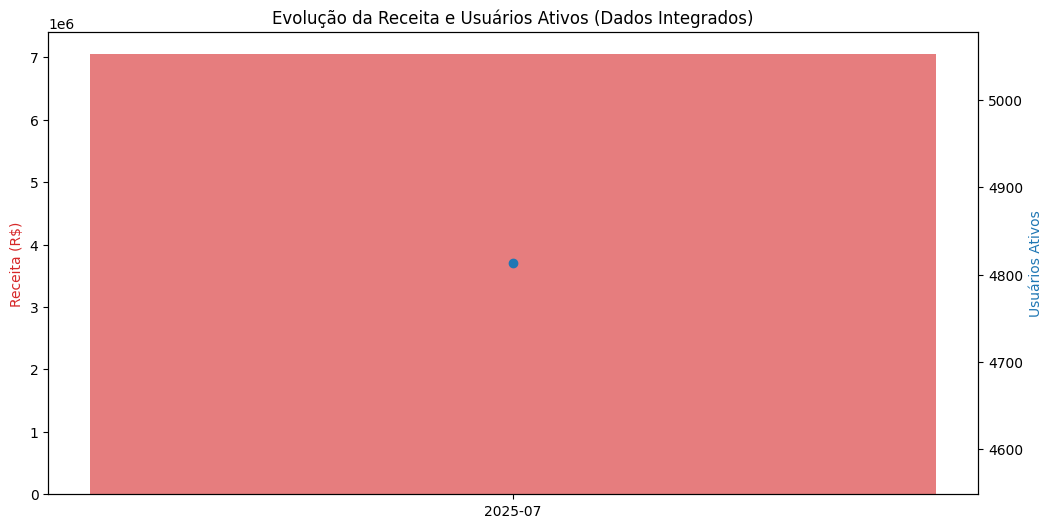


✅ Arquivo final INTEGRADO salvo para o Streamlit.
Total de Colunas para o Dashboard: 45


In [ ]:
# --- EXPLORAÇÃO E FORMATO FINAL ---

# 1. Evolução da Receita e Usuários Ativos (KPI) - Agora usando df_final
print("\n--- EXPLORAÇÃO: Evolução Mensal (KPI Atualizado) ---")

receita_mensal = df_final.groupby('mes_ano')['repasse_picmoney'].sum().reset_index()
usuarios_ativos = df_final.groupby('mes_ano')['celular'].nunique().reset_index()
usuarios_ativos.rename(columns={'celular': 'usuarios_ativos'}, inplace=True)

df_kpi = pd.merge(receita_mensal, usuarios_ativos, on='mes_ano')

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(df_kpi['mes_ano'], df_kpi['repasse_picmoney'], color='tab:red', alpha=0.6, label="Receita")
ax1.set_ylabel("Receita (R$)", color="tab:red")

ax2 = ax1.twinx()
ax2.plot(df_kpi['mes_ano'], df_kpi['usuarios_ativos'], color="tab:blue", marker="o", label="Usuários Ativos")
ax2.set_ylabel("Usuários Ativos", color="tab:blue")

plt.title("Evolução da Receita e Usuários Ativos (Dados Integrados)")
plt.xticks(rotation=45)
plt.show()

# 2. Exportação do Arquivo Final para o Streamlit (Formatar Dados)
try:
    df_final.to_excel("PicMoney_Dados_INTEGRADOS_PRONTOS_para_Streamlit.xlsx", index=False)
    print("\n✅ Arquivo final INTEGRADO salvo para o Streamlit.")
    print("Total de Colunas para o Dashboard:", len(df_final.columns))
except Exception as e:
    print(f"ERRO ao exportar: {e}")

#Simulação do arquivo final e exploração dos pedestres  


✅ Arquivo final INTEGRADO salvo com sucesso: PicMoney_Dados_INTEGRADOS_PRONTOS_para_Streamlit.xlsx
Total de Colunas no arquivo final: 45

--- EXPLORAÇÃO: Distribuição Demográfica (Pedestres) ---

Estatísticas de Idade:
count    100000.000000
mean         42.973140
std          15.836319
min          16.000000
25%          29.000000
50%          43.000000
75%          57.000000
max          70.000000
Name: idade, dtype: float64


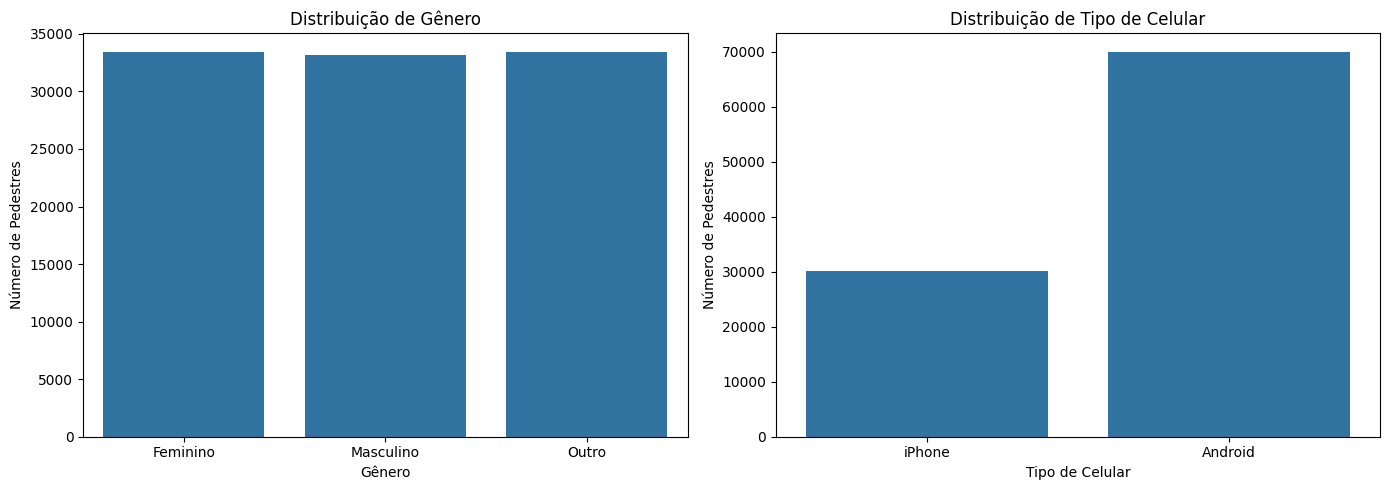

In [ ]:
# --- SIMULAÇÃO DO ARQUIVO FINAL E EXPLORAÇÃO DOS PEDESTRES (MODIFICADA) ---

# 1. EXPORTAÇÃO DO ARQUIVO FINAL INTEGRADO
try:
    # Exporta o DataFrame final, que é a fonte de dados para o Streamlit
    df_final.to_excel("PicMoney_Dados_INTEGRADOS_PRONTOS_para_Streamlit.xlsx", index=False)
    print("✅ Arquivo final INTEGRADO salvo com sucesso: PicMoney_Dados_INTEGRADOS_PRONTOS_para_Streamlit.xlsx")
    print("Total de Colunas no arquivo final:", len(df_final.columns))
except Exception as e:
    print(f"ERRO ao exportar: {e}")


# 2. EXPLORAÇÃO: Distribuição Demográfica (Pedestres) - Mantida
print("\n--- EXPLORAÇÃO: Distribuição Demográfica (Pedestres) ---")

# Análise de Idade
print("\nEstatísticas de Idade:")
print(df_pedestres_limpo['idade'].describe())

# Gráfico de barras para a distribuição de gênero
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='sexo', data=df_pedestres_limpo)
plt.title('Distribuição de Gênero')
plt.xlabel('Gênero')
plt.ylabel('Número de Pedestres')

# Gráfico de barras para a distribuição de tipo de celular
plt.subplot(1, 2, 2)
sns.countplot(x='tipo_celular', data=df_pedestres_limpo)
plt.title('Distribuição de Tipo de Celular')
plt.xlabel('Tipo de Celular')
plt.ylabel('Número de Pedestres')
plt.tight_layout()
plt.show()

#Resumo final do dataset + exploração


--- EXPLORAÇÃO: Distribuição Demográfica (Pedestres) ---

Estatísticas de Idade:
count    100000.000000
mean         42.973140
std          15.836319
min          16.000000
25%          29.000000
50%          43.000000
75%          57.000000
max          70.000000
Name: idade, dtype: float64


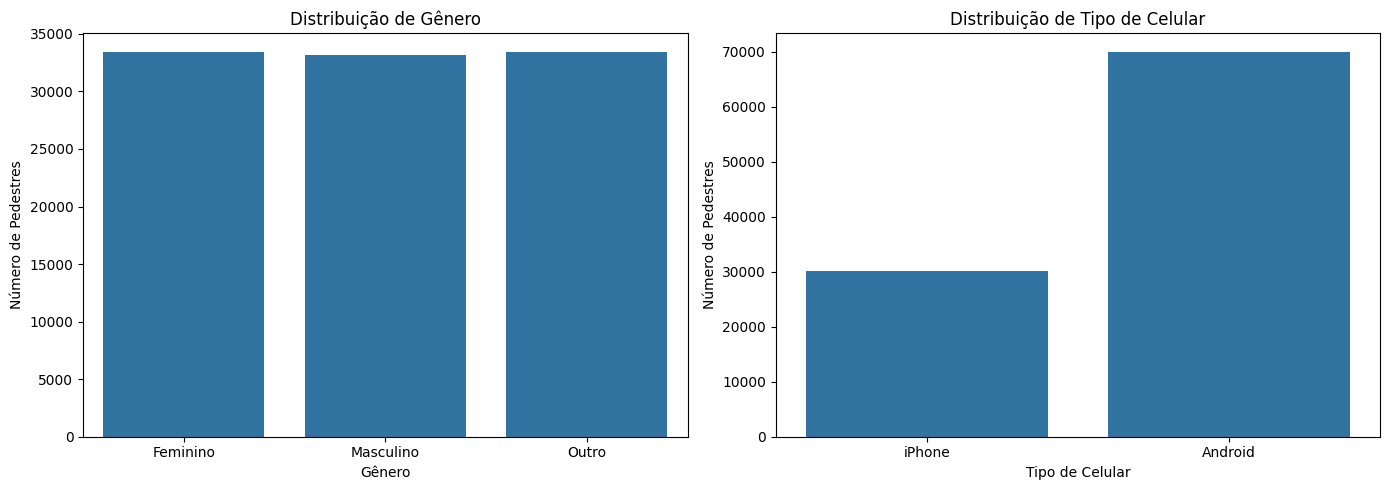

In [ ]:
#Resumo Final do Dataset + Exploração (Pedestres)

# --- Exploração (Pedestres) ---
print("\n--- EXPLORAÇÃO: Distribuição Demográfica (Pedestres) ---")

# Estatísticas de idade
print("\nEstatísticas de Idade:")
print(df_pedestres_limpo['idade'].describe())

# Gráfico de barras para a distribuição de gênero
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='sexo', data=df_pedestres_limpo)
plt.title('Distribuição de Gênero')
plt.xlabel('Gênero')
plt.ylabel('Número de Pedestres')


# Gráfico de barras para a distribuição de tipo de celular
plt.subplot(1, 2, 2)
sns.countplot(x='tipo_celular', data=df_pedestres_limpo)
plt.title('Distribuição de Tipo de Celular')
plt.xlabel('Tipo de Celular')
plt.ylabel('Número de Pedestres')
plt.tight_layout()
plt.show()